# HyDif: a two-component (hydrostatic + diffuse) gas profile

This notebook demonstrates `bfg.Profiles.HyDif`, an implementation of the two-component hot-gas
model from [Shavelle et al. 2026](https://arxiv.org/abs/2609.21861). HyDif splits a halo's hot
gas into a dense, approximately hydrostatic inner component (`HydrostaticGas`) and a diffuse,
extended outer component (`DiffuseGas`), with `Gas` combining the two into the total profile.

`HydrostaticGas`/`DiffuseGas` are deliberately agnostic to which baryonification model they're
paired with. Each takes:
- `darkmatter`: a one-halo dark-matter profile object (required) -- used to compute the total halo mass that the
  gas components are normalized against. A two-halo `DarkMatterOnly` composite should not be passed
  here; use its one-halo `DarkMatter` child instead.
- `Base`: an optional profile object whose `get_f_gas(...)` supplies the total gas fraction to
  split between the two components. If omitted, `darkmatter.get_f_gas(...)` is used instead (this works
  because `DarkMatter` classes in this package already inherit `get_f_gas`). HyDif treats the supplied
  total gas fraction as its hot-gas budget; if the source model separately includes cold or inner gas,
  that component is folded into the HyDif hydrostatic+diffuse budget.

Below we pair HyDif with both `Schneider19` and `Schneider25`, to show it plugging into either
pipeline without any HyDif-specific code change.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys, os; sys.path.insert(0, '../')
import BaryonForge as bfg
import pyccl as ccl

#Load cosmology object from CCL. Linear P(k) is needed since we use it for the two-halo term.
cosmo = ccl.Cosmology(Omega_c = 0.26, Omega_b = 0.04, h = 0.7, sigma8 = 0.8, n_s = 0.96, matter_power_spectrum = 'linear')
h = cosmo['h']

#Fiducial Schneider19 params
bpar_S19 = dict(theta_ej = 4, theta_co = 0.1, M_c = 1e14/h, mu_beta = 0.4,
                eta = 0.3, eta_delta = 0.3, tau = -1.5, tau_delta = 0,
                A = 0.09/2, M1 = 2.5e11/h, epsilon_h = 0.015,
                a = 0.3, n = 2, epsilon = 4, p = 0.3, q = 0.707, gamma = 2, delta = 7)

#Fiducial Schneider25 params
bpar_S25 = dict(epsilon0 = 4, epsilon1 = 0.5, alpha_excl = 0.4, p = 0.3, q = 0.707, M_c = 1e15, mu_beta = 0.8,
                q0 = 0.075, q1 = 0.25, q2 = 0.7, nu_q0 = 0, nu_q1 = 1, nu_q2 = 0, nstep = 3/2,
                theta_c = 0.3, nu_theta_c = 1/2, c_iga = 0.1, nu_c_iga = 3/2, r_min_iga = 1e-3, alpha = 1, gamma = 3/2, delta = 7,
                tau = -1.376, tau_delta = 0, Mstar = 3e11, Nstar = 0.03, eta = 0.1, eta_delta = 0.22, epsilon_cga = 0.03,
                alpha_nt = 0.1, nu_nt = 0.5, gamma_nt = 0.8, mean_molecular_weight = 0.6125)

#Fiducial HyDif params. M_c, mu, theta_d are set to the posterior means of the joint
#eROSITA+CMASS fit (Appendix A of Shavelle et al. 2026) -- the fit the paper highlights as
#describing the gas mass fractions "remarkably well" (the alternative HSC-XXL+CMASS fit gives
#log10 M_c=13.81, mu=1.43, theta_d=5.15 instead). The remaining shape parameters are the fixed
#values from Table 1 (not varied in either fit).
bpar_HyDif = dict(M_c = 10**14.38, mu = 0.69, theta_c = 0.1, gamma = 2.5,
                  beta_h = 2.7, delta_h = 7, theta_h = 3.5,
                  theta_d = 5.14, delta_d = 8, M_d = 1e15, mu_d = 1.0)

In [2]:
#Some plotting configs
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=22)
plt.rcParams["axes.linewidth"]  = 2.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]

## Plot the HyDif components against each pipeline's own gas profile

Left: paired with `Schneider19.DarkMatter` (so `Base` is omitted -- `get_f_gas` is inherited by
the darkmatter object). Right: paired with `Schneider25.DarkMatter` in the same way. In both panels we
compare HyDif's `HydrostaticGas`, `DiffuseGas`, and combined `Gas` against that pipeline's own
native gas profile. For Schneider25, the native profile distinguishes hot and inner gas, whereas
HyDif assigns the full fraction returned by `get_f_gas` to its hydrostatic+diffuse hot-gas budget;
the dotted native curve is therefore not a phase-by-phase comparison.

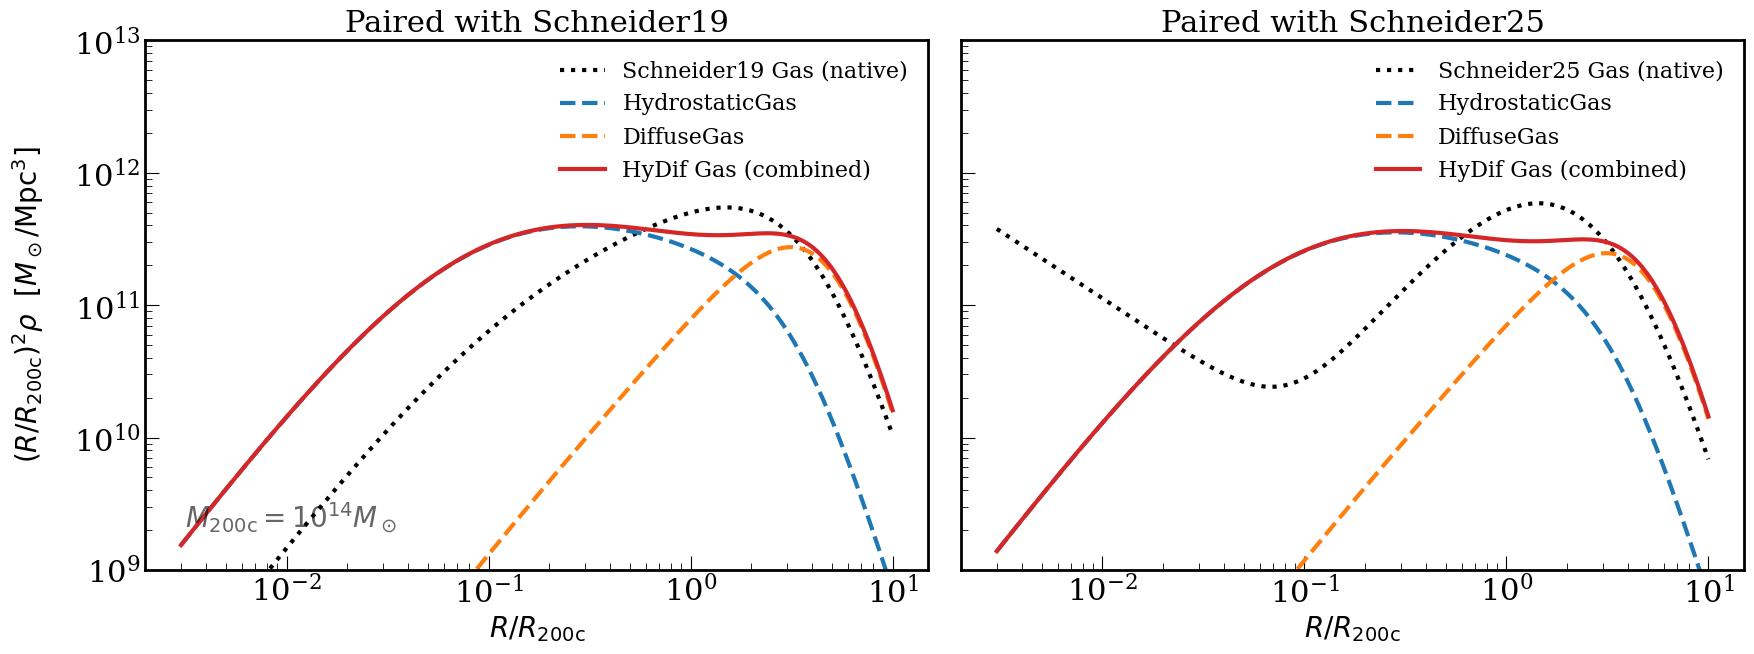

In [3]:
fig, ax = plt.subplots(1, 2, figsize = (18, 7), sharex = True, sharey = True)
[a.set_xscale('log') for a in ax]
[a.set_yscale('log') for a in ax]

M = 1e14 #Msun
a_scale = 1 #scale factor
mdef  = ccl.halos.massdef.MassDef200c
R200c = mdef.get_radius(cosmo, M, a_scale)
R = np.geomspace(0.003 * R200c, 10 * R200c, 500)
x = R/R200c

#--- Schneider19 pairing ---
DM_S19   = bfg.Profiles.Schneider19.DarkMatter(**bpar_S19)
GAS_S19  = bfg.Profiles.Schneider19.Gas(**bpar_S19)
HYD_S19  = bfg.Profiles.HyDif.HydrostaticGas(darkmatter = DM_S19, **bpar_HyDif)
DIF_S19  = bfg.Profiles.HyDif.DiffuseGas(darkmatter = DM_S19, **bpar_HyDif)
COMB_S19 = bfg.Profiles.HyDif.Gas(darkmatter = DM_S19, **bpar_HyDif)

ax[0].plot(x, x**2 * GAS_S19.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = ':', color = 'k', label = 'Schneider19 Gas (native)')
ax[0].plot(x, x**2 * HYD_S19.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = '--', label = 'HydrostaticGas')
ax[0].plot(x, x**2 * DIF_S19.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = '--', label = 'DiffuseGas')
ax[0].plot(x, x**2 * COMB_S19.real(cosmo, R, np.array(M), a_scale), lw = 3, color = 'C3', label = 'HyDif Gas (combined)')
ax[0].set_title('Paired with Schneider19', size = 22)

#--- Schneider25 pairing ---
DM_S25   = bfg.Profiles.Schneider25.DarkMatter(**bpar_S25)
GAS_S25  = bfg.Profiles.Schneider25.Gas(**bpar_S25)
HYD_S25  = bfg.Profiles.HyDif.HydrostaticGas(darkmatter = DM_S25, **bpar_HyDif)
DIF_S25  = bfg.Profiles.HyDif.DiffuseGas(darkmatter = DM_S25, **bpar_HyDif)
COMB_S25 = bfg.Profiles.HyDif.Gas(darkmatter = DM_S25, **bpar_HyDif)

ax[1].plot(x, x**2 * GAS_S25.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = ':', color = 'k', label = 'Schneider25 Gas (native)')
ax[1].plot(x, x**2 * HYD_S25.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = '--', label = 'HydrostaticGas')
ax[1].plot(x, x**2 * DIF_S25.real(cosmo, R, np.array(M), a_scale),  lw = 3, ls = '--', label = 'DiffuseGas')
ax[1].plot(x, x**2 * COMB_S25.real(cosmo, R, np.array(M), a_scale), lw = 3, color = 'C3', label = 'HyDif Gas (combined)')
ax[1].set_title('Paired with Schneider25', size = 22)

ax[0].set_ylim(1e9, 1e13)
ax[0].set_ylabel(r'$(R/R_{\rm 200c})^2\rho$  $[M_\odot/{\rm Mpc}^3]$', size = 20, labelpad = 20)
[a.set_xlabel(r'$R/R_{\rm 200c}$', size = 20) for a in ax]
[a.legend(fontsize = 16, frameon = False) for a in ax]
ax[0].text(0.05, 0.08, r'$M_{\rm 200c} = 10^{%d}M_\odot$' % int(np.log10(M)), size = 20,
          color = 'k', alpha = 0.6, ha = 'left', transform = ax[0].transAxes)
plt.tight_layout()
plt.show()

## Varying HyDif's free parameters

In the fiducial fit highlighted by the paper, `M_c`, `mu`, and `theta_d` are the three parameters
varied for the component fraction and diffuse extent. The remaining shape parameters are normally
held fixed at their fiducial values. For illustration, this notebook also varies three especially
important shape parameters: `theta_c` (the core radius, shared by both components), `beta_h`
(the hydrostatic component's inner cusp slope), and `gamma` (the shared intermediate-to-outer
transition sharpness).

Below we vary each of these six parameters in turn (holding the rest fixed at their fiducial
values), showing their effect on the combined `Gas` profile.

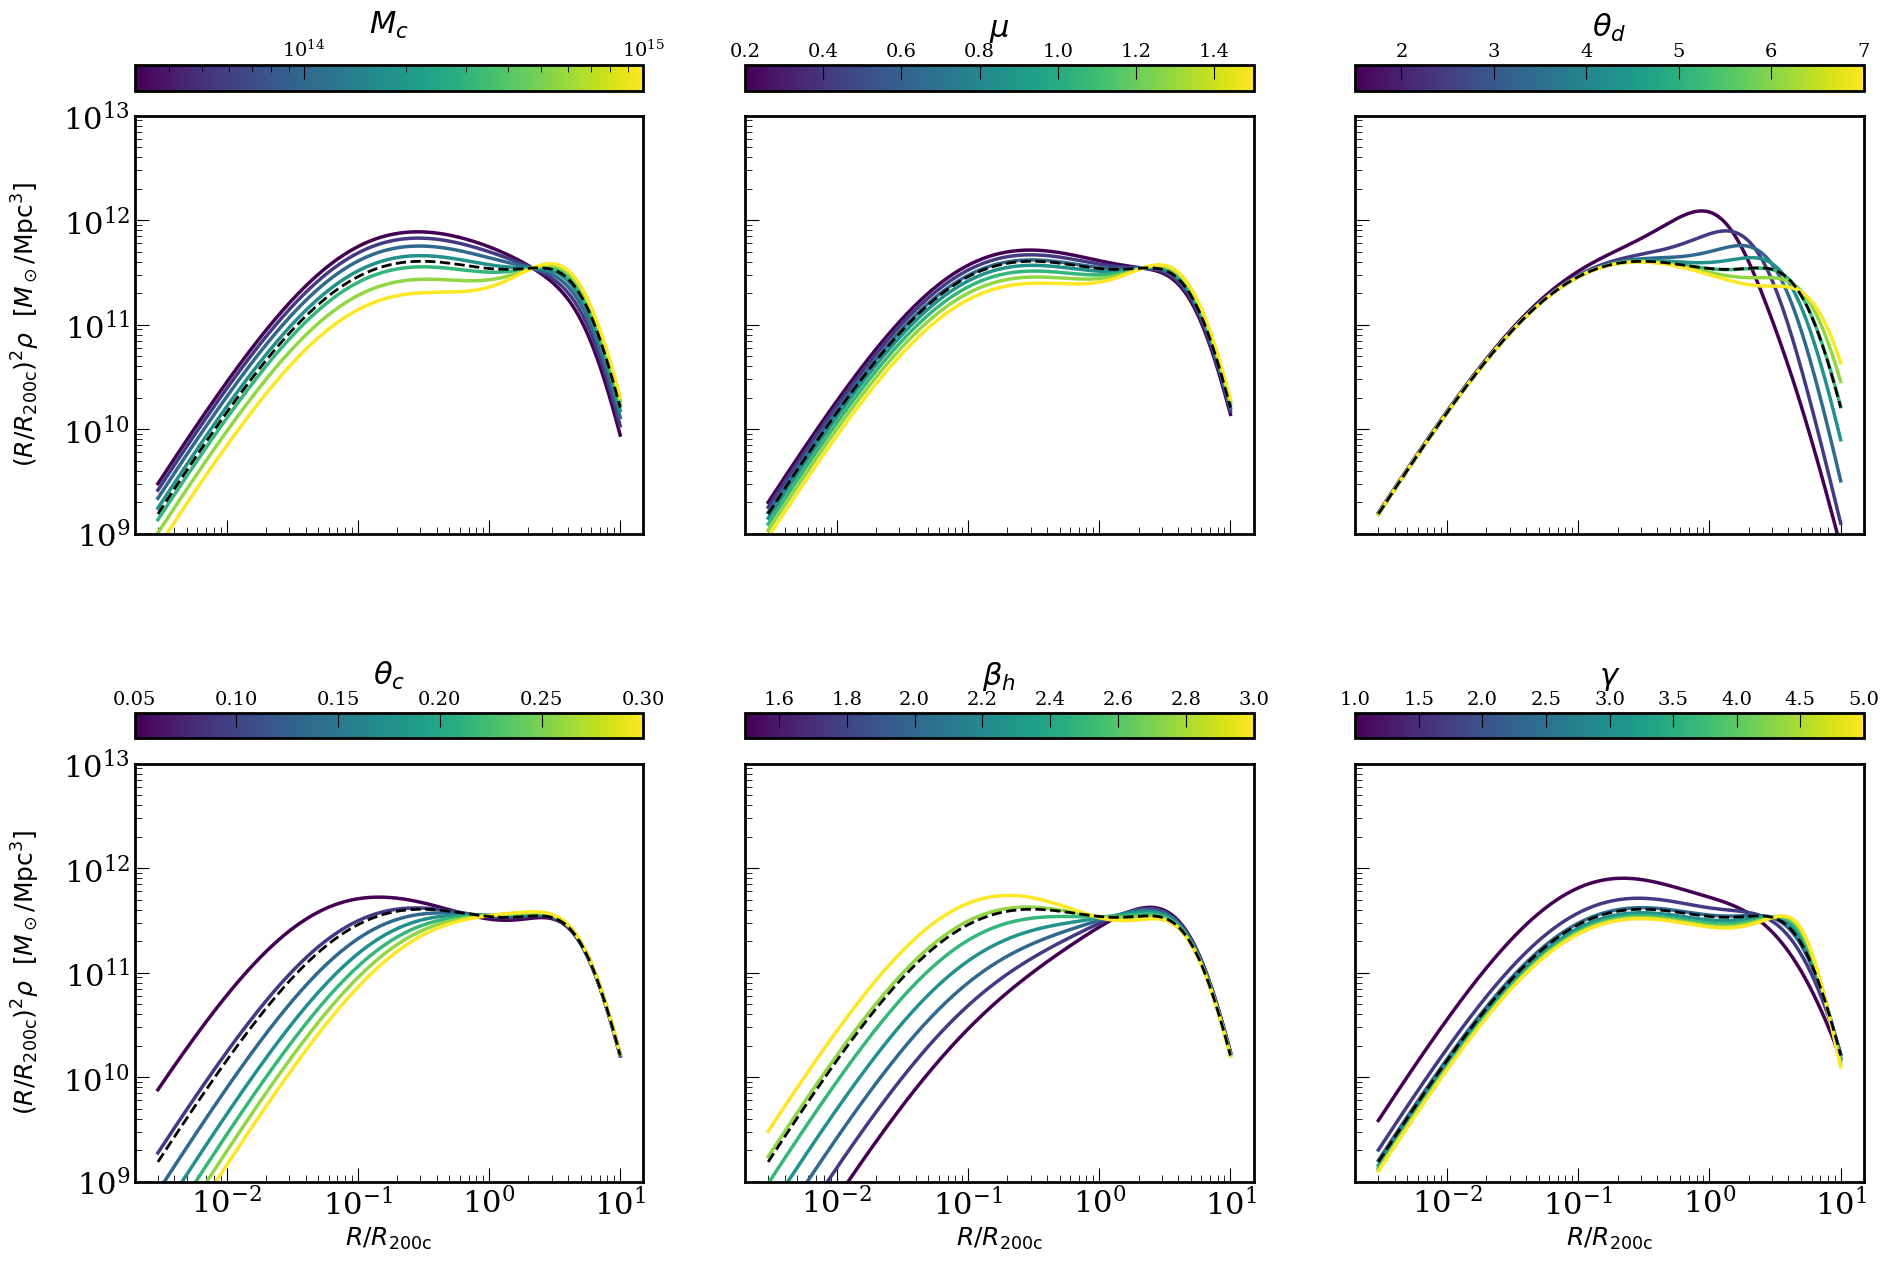

In [4]:
import matplotlib as mpl

fig, ax = plt.subplots(2, 3, figsize = (19, 13), sharex = True, sharey = True)
[a.set_xscale('log') for a in ax.flat]
[a.set_yscale('log') for a in ax.flat]

def bpar_HyDif_new(**overrides):
    return {**{k: v for k, v in bpar_HyDif.items() if k not in overrides}, **overrides}

#(param name, LaTeX symbol, values to sweep over, use a log-normalized colorbar)
variations = [
    ('M_c',     r'$M_c$',      np.geomspace(10**13.5, 10**15.0, 7), True),
    ('mu',      r'$\mu$',      np.linspace(0.2, 1.5, 7), False),
    ('theta_d', r'$\theta_d$', np.linspace(1.5, 7.0, 7), False),
    ('theta_c', r'$\theta_c$', np.linspace(0.05, 0.3, 7), False),
    ('beta_h',  r'$\beta_h$',  np.linspace(1.5, 3.0, 7), False),
    ('gamma',   r'$\gamma$',   np.linspace(1.0, 5.0, 7), False),
]

cmap = plt.get_cmap('viridis')

for a, (param, tex, values, use_log) in zip(ax.flat, variations):
    norm = mpl.colors.LogNorm(values.min(), values.max()) if use_log else mpl.colors.Normalize(values.min(), values.max())

    #Fiducial curve, for reference
    a.plot(x, x**2 * COMB_S19.real(cosmo, R, np.array(M), a_scale), lw = 2, ls = '--', color = 'k', zorder = 10)

    for v in values:
        GAS_VAR = bfg.Profiles.HyDif.Gas(darkmatter = DM_S19, **bpar_HyDif_new(**{param: v}))
        a.plot(x, x**2 * GAS_VAR.real(cosmo, R, np.array(M), a_scale), lw = 2.5, color = cmap(norm(v)))

    #Put the colorbar on top of the panel (not to the right) so it doesn't crowd the grid
    cax = a.inset_axes([0.0, 1.06, 1.0, 0.06])
    cb  = fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap = cmap), cax = cax, orientation = 'horizontal')
    cax.xaxis.set_ticks_position('top')
    cax.xaxis.set_label_position('top')
    cb.set_label(tex, size = 22, labelpad = 4)
    cb.ax.tick_params(labelsize = 14)

[a.label_outer() for a in ax.flat]
ax[0, 0].set_ylim(1e9, 1e13)
[a.set_ylabel(r'$(R/R_{\rm 200c})^2\rho$  $[M_\odot/{\rm Mpc}^3]$', size = 18, labelpad = 15) for a in ax[:, 0]]
[a.set_xlabel(r'$R/R_{\rm 200c}$', size = 18) for a in ax[-1, :]]

plt.subplots_adjust(hspace = 0.55, wspace = 0.2, top = 0.90, bottom = 0.08, left = 0.07, right = 0.98)
plt.show()

## Displacement function vs. the hydrostatic/diffuse component ratio and halo mass

Finally, we look at the effect of the hydrostatic/diffuse split on the baryonification
*displacement function* (see `02_Displacement_function.ipynb` for a general introduction),
and how that effect changes with halo mass. For a few representative halo masses (one panel
each), we build three `DarkMatterBaryon` profiles (paired with Schneider19), each using a
HyDif `Gas` whose `M_c` is chosen so that the component fraction `f_comp` at that panel's mass
takes a specific value -- mostly diffuse, balanced, and mostly hydrostatic -- while keeping the
total hot-gas fraction fixed. The HyDif gas and `DarkMatterBaryon` use the one-halo `DarkMatter`
profile; the `DarkMatterOnly` composite is used only as the DMO input to `Baryonification3D`.
We then compare their displacement functions directly.

This final section builds nine 3D displacement interpolators and is substantially more expensive
than the preceding profile plots. It is not necessary to rerun it just to inspect the displayed
results.

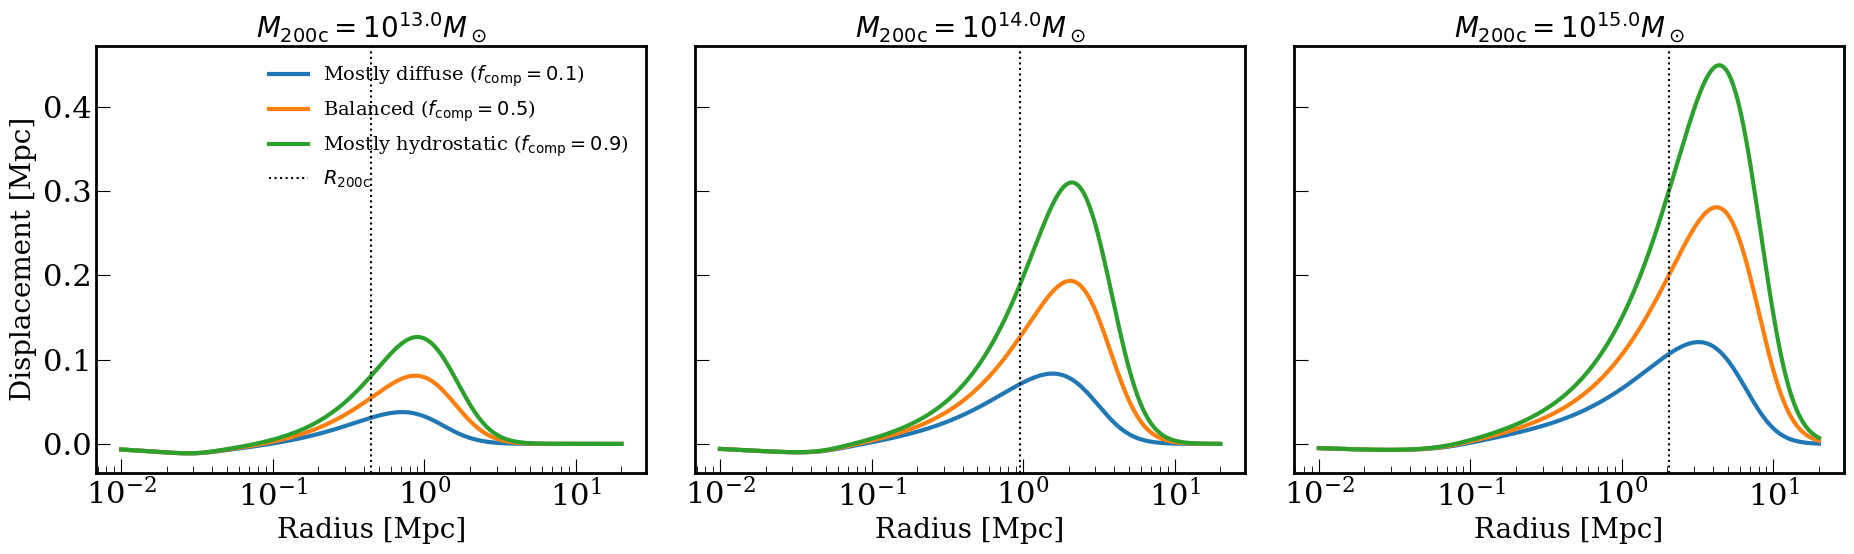

In [5]:
def Mc_for_fcomp(M, f_comp, mu):
    """Solve Eq. 4 of Shavelle et al. 2026 for the M_c that gives a target f_comp at mass M."""
    return M / (1/f_comp - 1)**(1/mu)

masses = [1e13, 1e14, 1e15] #Msun -- one panel per mass
f_comp_targets = [0.1, 0.5, 0.9]
labels = ['Mostly diffuse', 'Balanced', 'Mostly hydrostatic']

DM_S19 = bfg.Profiles.Schneider19.DarkMatter(**bpar_S19)
DMO_S19 = bfg.Profiles.Schneider19.DarkMatterOnly(darkmatter = DM_S19, **bpar_S19)

fig, ax = plt.subplots(1, 3, figsize = (19, 6), sharex = True, sharey = True)

for a, M_i in zip(ax, masses):
    a.set_xscale('log')

    for f_comp, label in zip(f_comp_targets, labels):
        Mc_i  = Mc_for_fcomp(M_i, f_comp, bpar_HyDif['mu'])
        GAS_i = bfg.Profiles.HyDif.Gas(darkmatter = DM_S19, **bpar_HyDif_new(M_c = Mc_i))
        DMB_i = bfg.Profiles.Schneider19.DarkMatterBaryon(gas = GAS_i, darkmatter = DM_S19, **bpar_S19)

        Displacement = bfg.Profiles.Baryonification3D(DMO_S19, DMB_i, cosmo = cosmo)
        Displacement.setup_interpolator(z_min = 0, z_max = 1, N_samples_z = 2, z_linear_sampling = True,
                                        M_min = 1e12, M_max = 1e16, N_samples_Mass = 5,
                                        R_min = 1e-3, R_max = 50, N_samples_R = 300, verbose = False)

        R_arr = np.geomspace(1e-2, 20, 200)
        a.plot(R_arr, Displacement.displacement(R_arr, M_i, 1), lw = 3,
                label = r'%s ($f_{\rm comp} = %.1f$)' % (label, f_comp))

    a.axvline(mdef.get_radius(cosmo, M_i, 1), color = 'k', ls = ':', label = r'$R_{\rm 200c}$' if M_i == masses[0] else None)
    a.set_title(r'$M_{\rm 200c} = 10^{%.1f} M_\odot$' % np.log10(M_i), size = 20)
    a.set_xlabel('Radius [Mpc]', size = 20)

ax[0].set_ylabel('Displacement [Mpc]', size = 20)
ax[0].legend(fontsize = 14, frameon = False)
plt.tight_layout()
plt.show()